# 1-D estuary: recreating the manuscript mechanism figures with `hydromend`

This notebook reproduces the lag-operator mechanism experiments from the paper's
1-D shallow-water study, but does **all** of the post-processing with the
`hydromend` package instead of the paper's bespoke `lag_analysis_utils` code.

The recipe is unchanged in spirit:

1. run a **1-D shallow-water estuary solver** twice per experiment — a
   *baseline* (reduced physics) and a *target* (full physics / real geometry) —
   and record the water level at one station;
2. learn a **lag operator** that maps baseline → target, comparing a **linear**
   kernel with a **bilinear** (second-order Volterra) kernel;
3. evaluate out-of-sample and read off the **impulse response** and the
   **Volterra kernel** *K(τ₁,τ₂)*.

Only step 2–3 change: where the paper hand-rolled `make_lag_matrix`,
`make_bilinear_features`, `ARDRegression`, and `extract_bilinear_kernel`, we call
`hydromend.build_feature_set`, `hydromend.make_regressor` (whose default
`vb_ard` **is** the variational-Bayes ARD estimator the paper used), and
`hydromend.extract_linear_lag_weights` / `extract_bilinear_lag_surface`.

> Runtime is kept modest (smaller domain, coarser Δt, ~60-day runs). Bump `NX`,
> lower `DT`, and raise `TRAIN_DAYS` toward the paper's settings for
> publication-quality kernels.

## 1. The physics — the 1-D shallow-water solver

This cell is the paper's estuary solver, unchanged except `@njit(cache=False)`
(so it compiles cleanly inside a notebook). Scenarios toggle the non-linear
terms: `S1_no` (linear), `S2_wave` (depth-dependent transport `H·u`), `S3_invH`
(depth-dependent momentum source `1/H`), `S4_full` (both).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit


# ===================================================================
# Tidal boundary condition
# ===================================================================
def tide_bc(t, A_M2=4.0, A_S2=1.5,
            omega_M2=2*np.pi/(12.42*3600.0),
            omega_S2=2*np.pi/(12.00*3600.0)):
    """
    Two-constituent tide: M2 + S2.
    Beat period ≈ 14.8 days (spring-neap cycle).
    """
    return A_M2 * np.cos(omega_M2 * t) + A_S2 * np.cos(omega_S2 * t)


# ===================================================================
# Storm schedule generator
# ===================================================================
def make_storm_schedule(
    T_total_s, mean_storm_dur_s, n_storms, rng=None,
    min_gap_s=6*3600.0, tau0_mean=1.0, tau0_sd=0.3,
    dur_sd_frac=0.25, dir_mean_deg=0.0, dir_sd_deg=45.0,
):
    if rng is None:
        rng = np.random.default_rng()

    required = n_storms * (mean_storm_dur_s + min_gap_s)
    if required > T_total_s:
        raise ValueError("Cannot fit storms; reduce n_storms or constraints.")

    slack = T_total_s - n_storms * (mean_storm_dur_s + min_gap_s)
    raw = np.sort(rng.uniform(0, slack, n_storms))
    onsets = raw + np.arange(n_storms) * (mean_storm_dur_s + min_gap_s)

    tau0s = np.maximum(0.05, rng.normal(tau0_mean, tau0_sd, n_storms))
    durs  = np.maximum(3600.0, rng.normal(
                mean_storm_dur_s, dur_sd_frac * mean_storm_dur_s, n_storms))
    dirs  = rng.normal(dir_mean_deg, dir_sd_deg, n_storms)

    return [
        {"onset": float(onsets[i]), "dur": float(durs[i]),
         "tau0": float(tau0s[i]),   "dir_deg": float(dirs[i])}
        for i in range(n_storms)
    ]


def multi_wind_forcing(t, storms, fetch_factor=1.0, gust_sd=0.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    for s in storms:
        t0 = s["onset"]
        t1 = t0 + s["dur"]
        if t0 <= t <= t1:
            s_rel = (t - t0) / s["dur"]
            base = s["tau0"] * (np.sin(np.pi * s_rel) ** 2)
            dir_factor = max(0.0, np.cos(np.deg2rad(s["dir_deg"])))
            gust = float(rng.normal(0.0, gust_sd)) if gust_sd > 0 else 0.0
            return (base * dir_factor * fetch_factor) + gust
    return 0.0


# ===================================================================
# Numba-compiled inner loop
# ===================================================================
@njit(cache=False)
def _swe_loop(
    Nt, dt, dx, output_stride,
    h_c, h_f,
    b_c, b_f,
    continuity_uses_H, invH_uses_H,
    ix0,
    eta_bc_arr,
    ramp_arr,
    tauw_arr,
    Q_river_arr,
    g, rho, Cd_f, min_depth,
    sponge_coeff_f,        # Rayleigh velocity damping at faces
    sponge_coeff_c_eta,    # eta nudging weight at centres (0 = off)
):
    Nx = len(h_c)
    eta = np.zeros(Nx)
    u   = np.zeros(Nx + 1)

    n_out = Nt // output_stride + 1
    t_hist    = np.empty(n_out)
    eta_x0    = np.empty(n_out)
    u_x0      = np.empty(n_out)
    wind_hist = np.empty(n_out)
    i_out = 0

    delta2 = min_depth * min_depth

    for n in range(Nt):
        t = n * dt

        # --- total depth at centres and faces --------------------------
        H_c = np.maximum(h_c + eta, min_depth)

        H_f = np.empty(Nx + 1)
        for i in range(1, Nx):
            H_f[i] = 0.5 * (H_c[i-1] + H_c[i])
        H_f[0]  = H_c[0]
        H_f[-1] = H_c[-1]
        for i in range(Nx + 1):
            if H_f[i] < min_depth:
                H_f[i] = min_depth

        if continuity_uses_H:
            Hflux_f = H_f
        else:
            Hflux_f = h_f

        # --- regularised 1/H ------------------------------------------
        invH_c = np.empty(Nx)
        for i in range(Nx):
            base = H_c[i] if invH_uses_H else max(h_c[i], min_depth)
            invH_c[i] = base / (base * base + delta2)

        invH_f = np.empty(Nx + 1)
        for i in range(1, Nx):
            invH_f[i] = 0.5 * (invH_c[i-1] + invH_c[i])
        invH_f[0]  = invH_c[0]
        invH_f[-1] = invH_c[-1]

        tauw = tauw_arr[n]

        # --- pressure gradient at faces --------------------------------
        deta_dx_f = np.zeros(Nx + 1)
        for i in range(1, Nx):
            deta_dx_f[i] = (eta[i] - eta[i-1]) / dx

        # --- semi-implicit momentum + velocity sponge ------------------
        # The Rayleigh term gamma*u in the denominator absorbs
        # overtide kinetic energy without forcing eta toward any
        # particular value, so surge is preserved.
        u_new = np.empty(Nx + 1)
        for i in range(1, Nx):
            rhs   = u[i] + dt * (-g * deta_dx_f[i] + (tauw / rho) * invH_f[i])
            denom = 1.0 + dt * Cd_f[i] * abs(u[i]) * invH_f[i] + sponge_coeff_f[i]
            u_new[i] = rhs / denom

        # --- left BC: radiation (tidal open boundary) ------------------
        eta_bc_next = eta_bc_arr[n]
        c0   = (g * H_f[0]) ** 0.5
        covH = c0 / H_f[0]
        R_plus  = 2.0 * covH * eta_bc_next
        R_minus = u[1] - covH * eta[0]
        u_new[0] = 0.5 * (R_plus + R_minus)

        # --- right BC: river inflow or wall ----------------------------
        Q_r = Q_river_arr[n]
        if Q_r == 0.0:
            u_new[-1] = 0.0
        else:
            # Regularised: floor H at min_depth to prevent velocity spikes
            # at low tide.  The flux limiter in continuity handles mass
            # conservation; this just prevents the velocity from blowing up.
            H_land = max(H_f[-1], min_depth)
            bH = b_f[-1] * H_land
            u_new[-1] = -Q_r / bH

        # --- continuity: b * deta/dt + d(b*H*u)/dx = 0 ----------------
        flux = np.empty(Nx + 1)
        for i in range(Nx + 1):
            flux[i] = b_f[i] * Hflux_f[i] * u_new[i]

        # flux limiter
        for i in range(Nx):
            eta_cand = eta[i] - dt * (flux[i+1] - flux[i]) / (b_c[i] * dx)
            if h_c[i] + eta_cand < min_depth:
                H_avail = max(h_c[i] + eta[i] - min_depth, 0.0)
                net_out = (flux[i+1] - flux[i]) / (b_c[i] * dx)
                if net_out > 0.0:
                    scale = H_avail / (net_out * dt + 1e-12)
                    if scale < 1.0:
                        flux[i+1] *= scale
                        flux[i]   *= scale

        eta_new = np.empty(Nx)
        for i in range(Nx):
            eta_new[i] = eta[i] - dt * (flux[i+1] - flux[i]) / (b_c[i] * dx)

        # --- optional eta nudging toward tidal BC ----------------------
        # OFF by default.  When enabled, this relaxes eta toward the
        # prescribed tidal signal, which removes overtide jaggedness
        # but ALSO damps the surge component (since eta_bc has no surge).
        # Use only for short diagnostic runs where clean time series
        # matter more than surge amplitude fidelity.
        for i in range(Nx):
            alpha = sponge_coeff_c_eta[i]
            if alpha > 0.0:
                eta_new[i] = (1.0 - alpha) * eta_new[i] + alpha * eta_bc_next

        eta = eta_new
        u   = u_new

        if n % output_stride == 0 and i_out < n_out:
            t_hist[i_out]    = t
            eta_x0[i_out]    = eta[ix0]
            u_x0[i_out]      = u[ix0]
            wind_hist[i_out] = tauw
            i_out += 1

    return (
        t_hist[:i_out],
        eta_x0[:i_out],
        u_x0[:i_out],
        wind_hist[:i_out],
    )


# ===================================================================
# Precompute forcing arrays
# ===================================================================
def _precompute_forcing(Nt, dt, storms, A_tide, omega_M2, omega_S2,
                        with_wind, Q_river_func):
    t_arr = np.arange(Nt) * dt

    T_ramp = 2 * (2 * np.pi / omega_M2)
    ramp_arr = np.where(
        t_arr + dt >= T_ramp,
        1.0,
        0.5 * (1 - np.cos(np.pi * (t_arr + dt) / T_ramp))
    )

    eta_bc_arr = (
        A_tide * ramp_arr * np.cos(omega_M2 * (t_arr + dt)) +
        A_tide * 0.35 * ramp_arr * np.cos(omega_S2 * (t_arr + dt))
    )

    tauw_arr = np.zeros(Nt)
    if with_wind:
        for s in storms:
            t0, t1 = s["onset"], s["onset"] + s["dur"]
            dir_factor = max(0.0, np.cos(np.deg2rad(s["dir_deg"])))
            mask = (t_arr >= t0) & (t_arr <= t1)
            if np.any(mask):
                s_rel = (t_arr[mask] - t0) / s["dur"]
                tauw_arr[mask] = s["tau0"] * np.sin(np.pi * s_rel) ** 2 * dir_factor

    Q_river_arr = np.zeros(Nt)
    if Q_river_func is not None:
        for i in range(Nt):
            Q_river_arr[i] = Q_river_func(t_arr[i])

    return eta_bc_arr, ramp_arr, tauw_arr, Q_river_arr


# ===================================================================
# Sponge layer construction
# ===================================================================
def _build_sponge(Nx, dx, L,
                  sponge_frac=0.15,
                  sponge_vel_max=0.02,
                  sponge_eta_max=0.0,
                  sponge_land_frac=0.0,
                  sponge_land_vel_max=0.0):
    """
    Build sponge coefficient arrays at one or both ends of the domain.

    Seaward sponge (near x = 0):
      sponge_frac      — fraction of domain covered
      sponge_vel_max   — Rayleigh velocity damping (default ON, 0.02).
          Surge-safe: absorbs overtide KE without forcing eta.
      sponge_eta_max   — eta nudging toward tidal BC (default OFF).
          Damps surge; use only for short diagnostic runs.

    Landward sponge (near x = L):
      sponge_land_frac     — fraction of domain covered (default 0 = off)
      sponge_land_vel_max  — Rayleigh velocity damping (default 0 = off).
          Absorbs overtides reflecting off the river/wall BC.
          Mimics the high friction in the shallow upstream reach
          of a real estuary.  Velocity-only, so river setup and
          surge propagation are preserved.
    """
    x_c = (np.arange(Nx) + 0.5) * dx
    x_f = np.arange(Nx + 1) * dx

    # --- seaward sponge (x = 0) ---
    L_sea = sponge_frac * L
    sponge_f = np.zeros(Nx + 1)
    if sponge_vel_max > 0.0:
        for i in range(Nx + 1):
            if x_f[i] < L_sea:
                sponge_f[i] = sponge_vel_max * ((L_sea - x_f[i]) / L_sea) ** 2

    sponge_c_eta = np.zeros(Nx)
    if sponge_eta_max > 0.0:
        for i in range(Nx):
            if x_c[i] < L_sea:
                sponge_c_eta[i] = sponge_eta_max * ((L_sea - x_c[i]) / L_sea) ** 2

    # --- landward sponge (x = L) — velocity damping only ---
    if sponge_land_vel_max > 0.0 and sponge_land_frac > 0.0:
        L_land = sponge_land_frac * L
        x_land_start = L - L_land
        for i in range(Nx + 1):
            if x_f[i] > x_land_start:
                val = sponge_land_vel_max * ((x_f[i] - x_land_start) / L_land) ** 2
                sponge_f[i] = max(sponge_f[i], val)   # take max if overlap

    return sponge_f, sponge_c_eta


# ===================================================================
# Estuary geometry builder
# ===================================================================
def build_geometry(
    L, Nx, *,
    h0=12.0,
    h_river=3.0,
    slope=0.0,
    estuary=False,
    b_mouth=5000.0,
    b_head=200.0,
    Lb=None,
    min_depth=0.5,
):
    dx  = L / Nx
    x_c = (np.arange(Nx) + 0.5) * dx
    x_f = np.arange(Nx + 1) * dx

    if estuary:
        h_c = h0 + (h_river - h0) * (x_c / L)
    else:
        h_c = h0 + slope * (x_c - x_c.mean())

    h_c = np.maximum(h_c, min_depth)

    h_f = np.empty(Nx + 1)
    h_f[1:-1] = 0.5 * (h_c[:-1] + h_c[1:])
    h_f[0] = h_c[0]; h_f[-1] = h_c[-1]
    h_f = np.maximum(h_f, min_depth)

    if estuary:
        if Lb is None:
            Lb = -L / np.log(b_head / b_mouth)
        b_c = b_mouth * np.exp(-x_c / Lb)
        b_f = b_mouth * np.exp(-x_f / Lb)
        b_c = np.maximum(b_c, b_head)
        b_f = np.maximum(b_f, b_head)
    else:
        b_c = np.ones(Nx)
        b_f = np.ones(Nx + 1)

    return h_c, h_f, b_c, b_f


# ===================================================================
# River discharge helpers
# ===================================================================
def constant_river(Q):
    def _f(t):
        return Q
    return _f


def seasonal_river(Q_base=50.0, Q_peak=400.0, t_peak_day=45.0,
                   flood_width_days=30.0):
    t_peak_s = t_peak_day * 86400.0
    sigma_s  = flood_width_days * 86400.0
    def _f(t):
        return Q_base + (Q_peak - Q_base) * np.exp(
            -0.5 * ((t - t_peak_s) / sigma_s) ** 2
        )
    return _f


# ===================================================================
# Plotting
# ===================================================================
def plot_scatter_with_trend(
    df_cycles,
    filterval=200000,
    *,
    by="scenario",
    title="Predicted High Water vs Synthetic Skew Surge"
):
    scenario_labels = {
        "S1_no":   "Linear (No Interaction)",
        "S2_wave": r"$\sqrt{g(h + \eta)}$ Depth-Dependent Transport",
        "S3_invH": "1/H Wind Scaling",
        "S4_full": "Full Interaction"
    }

    if by == "scenario":
        ordered = ["S1_no", "S2_wave", "S3_invH", "S4_full"]
        scenarios = [s for s in ordered if s in df_cycles["scenario"].unique()]

        fig, axes = plt.subplots(
            1, len(scenarios),
            figsize=(5 * len(scenarios), 5),
            sharey=False
        )
        if len(scenarios) == 1:
            axes = [axes]

        for ax, scen in zip(axes, scenarios):
            d = df_cycles[df_cycles["scenario"] == scen].dropna()
            d = d[d.t0_s > filterval]
            x = d["predicted_HW_m"].to_numpy()
            y = d["skew_surge_m"].to_numpy()

            ax.scatter(x, y, color="black", s=25, alpha=0.5)

            if len(x) >= 2 and np.std(x) > 1e-10:
                m, b = np.polyfit(x, y, 1)
                xx = np.linspace(x.min(), x.max(), 200)
                ax.plot(xx, m * xx + b, color="red", linewidth=4)
                subtitle = f"Slope = {m:.3f} m/m"
            else:
                subtitle = "Slope = —"

            label = scenario_labels.get(scen, scen)
            ax.set_title(f"{label}\n{subtitle}", fontsize=11)
            ax.set_xlabel("Predicted High Water (m)", fontsize=11)

        axes[0].set_ylabel("Synthetic Skew Surge (m)", fontsize=11)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.savefig("1d_model_result.png", dpi=300, bbox_inches='tight')
        plt.show()


# ===================================================================
# Public solver
# ===================================================================
def run_1d_swe(
    scenario, with_wind, storms,
    *,
    L=100e3, Nx=400,
    T=60*86400.0, dt=7.5, output_every=600,
    h0=12.0, slope=0.00,
    # estuary
    estuary=False,
    h_river=3.0,
    b_mouth=5000.0,
    b_head=200.0,
    Lb=None,
    Q_river_func=None,
    # tidal forcing
    A_tide=4.0,
    omega_M2=2*np.pi/(12.42*3600.0),
    omega_S2=2*np.pi/(12.00*3600.0),
    # physics
    rho=1025.0, g=9.81, Cd=0.0025, min_depth=0.5,
    Cd_depth_scale=None,     # reference depth for enhanced friction (None = off)
    storm_dur=18*3600.0, tau0=0.8, x0_frac=0.8,
    # sponge — independent controls for each end
    sponge_frac=0.15,
    sponge_vel_max=0.02,     # velocity damping near x=0 (ON by default)
    sponge_eta_max=0.0,      # eta nudging near x=0     (OFF by default)
    sponge_land_frac=None,   # velocity damping near x=L (auto for estuary)
    sponge_land_vel_max=None,
):
    """
    1-D shallow-water solver for shelf or estuary.

    Friction:
      Cd            : base drag coefficient (uniform in deep water).
      Cd_depth_scale: reference depth for depth-dependent friction.
          Cd_eff(x) = Cd * max(1, Cd_depth_scale / h(x)).
          In shallow water (h < h_ref), friction increases as h_ref/h,
          consistent with Manning-Strickler scaling.  This damps
          overtides at their source in the shallow estuarine head.
          Default: auto (= h0 when estuary=True, off for shelf).
          Set to 0 to disable, or to a specific depth to control.

    Sponge layer controls:
      sponge_vel_max : Rayleigh damping on velocity near x=0.
          Absorbs overtide kinetic energy.  Surge-safe.  Default ON.

      sponge_eta_max : Nudging of eta toward tidal BC near x=0.
          Damps surge; default OFF.  Use for short regression runs.

      sponge_land_frac / sponge_land_vel_max :
          Velocity damping near x=L (the landward end).
          Defaults to ON when Q_river_func is set.
    """
    assert scenario in {"S1_no", "S2_wave", "S3_invH", "S4_full"}

    dx = L / Nx

    h_c, h_f, b_c, b_f = build_geometry(
        L, Nx, h0=h0, h_river=h_river, slope=slope,
        estuary=estuary,
        b_mouth=b_mouth, b_head=b_head, Lb=Lb,
        min_depth=min_depth,
    )

    continuity_uses_H = scenario in {"S2_wave", "S4_full"}
    invH_uses_H       = scenario in {"S3_invH", "S4_full"}
    ix0 = int(np.clip(round(x0_frac * (Nx - 1)), 0, Nx - 1))

    # --- depth-dependent friction -------------------------------------
    # Cd_f(x) = Cd * max(1, h_ref / h_f(x))
    # When Cd_depth_scale is None: auto-enable for estuary (h_ref = h0),
    # leave uniform for shelf.
    # When h_f = h0 everywhere (flat bed), Cd_f = Cd — no change.
    # In shallow water (h_f < h_ref), friction increases as h_ref/h,
    # consistent with Manning-Strickler.  This damps overtides at
    # their source in the shallow estuarine head.
    _h_ref = Cd_depth_scale
    if _h_ref is None:
        _h_ref = h0 if estuary else 0.0    # 0 means no enhancement

    Cd_f = np.full(Nx + 1, Cd)
    if _h_ref > 0.0:
        for i in range(Nx + 1):
            Cd_f[i] = Cd * max(1.0, _h_ref / max(h_f[i], min_depth))

    Nt            = int(np.floor(T / dt))
    output_stride = max(1, int(round(output_every / dt)))

    eta_bc_arr, ramp_arr, tauw_arr, Q_river_arr = _precompute_forcing(
        Nt, dt, storms, A_tide, omega_M2, omega_S2,
        with_wind, Q_river_func,
    )

    # Auto-enable landward sponge for estuary + river
    _land_frac = sponge_land_frac
    _land_vel  = sponge_land_vel_max
    if _land_frac is None:
        _land_frac = 0.15 if Q_river_func is not None else 0.0
    if _land_vel is None:
        _land_vel  = 0.02 if Q_river_func is not None else 0.0

    sponge_f, sponge_c_eta = _build_sponge(
        Nx, dx, L, sponge_frac, sponge_vel_max, sponge_eta_max,
        _land_frac, _land_vel,
    )

    t_h, eta_h, u_h, wind_h = _swe_loop(
        Nt, dt, dx, output_stride,
        h_c, h_f, b_c, b_f,
        continuity_uses_H, invH_uses_H,
        ix0,
        eta_bc_arr, ramp_arr, tauw_arr,
        Q_river_arr,
        g, rho, Cd_f, min_depth,
        sponge_f, sponge_c_eta,
    )

    return pd.DataFrame({
        "t_s"       : t_h,
        "t_hr"      : t_h / 3600.0,
        "scenario"  : scenario,
        "with_wind" : with_wind,
        "eta_x0_m"  : eta_h,
        "u_x0_mps"  : u_h,
        "tauw_Pa"   : wind_h,
    })


# ===================================================================
# Skew-surge extraction
# ===================================================================
def compute_cycle_skew_surge(df_tide, df_tw, period_s, storms, storm_dur_s=None):
    t        = df_tide["t_s"].to_numpy()
    n_cycles = int(np.floor(t.max() / period_s))

    onsets = np.array([s["onset"] for s in storms])
    durs   = np.array([s["dur"]   for s in storms])
    ends   = onsets + durs
    sort_idx = np.argsort(onsets)
    onsets_s = onsets[sort_idx]
    ends_s   = ends[sort_idx]

    eta_tide = df_tide["eta_x0_m"].to_numpy()
    eta_tw   = df_tw["eta_x0_m"].to_numpy()

    rows = []
    for k in range(n_cycles):
        t0 = k * period_s
        t1 = t0 + period_s
        m  = (t >= t0) & (t < t1)
        if not np.any(m):
            continue

        i_lo = np.searchsorted(onsets_s, t1, side="left")
        storm_in_cycle = np.any(ends_s[:i_lo] > t0)

        if not storm_in_cycle:
            continue

        rows.append({
            "cycle"          : k,
            "t0_s"           : t0,
            "t1_s"           : t1,
            "predicted_HW_m" : eta_tide[m].max(),
            "skew_surge_m"   : eta_tw[m].max() - eta_tide[m].max(),
        })

    return pd.DataFrame(rows)


# ===================================================================
# Sweep
# ===================================================================
def run_sweep(
    *,
    scenarios=("S1_no", "S2_wave", "S3_invH", "S4_full"),
    T_days=365,
    n_storms=140,
    A_tide=4.0,
    tau0=1.0,
    storm_dur_hr=18.0,
    dt=7.5,
    output_every=600,
    seed=42,
    estuary=False,
    h_river=3.0,
    b_mouth=5000.0,
    b_head=200.0,
    Lb=None,
    Q_river_func=None,
    **swe_kwargs,
):
    omega      = 2 * np.pi / (12.42 * 3600.0)
    period_s   = 2 * np.pi / omega
    T_s        = T_days * 86400.0
    storm_dur_s = storm_dur_hr * 3600.0

    rng = np.random.default_rng(seed)
    storm_onsets = make_storm_schedule(T_s, storm_dur_s, n_storms, rng=rng)

    all_ts, all_cycles = [], []

    for scen in scenarios:
        common = dict(
            T=T_s, dt=dt, output_every=output_every,
            A_tide=A_tide, tau0=tau0, storm_dur=storm_dur_s,
            estuary=estuary, h_river=h_river,
            b_mouth=b_mouth, b_head=b_head, Lb=Lb,
            Q_river_func=Q_river_func,
            **swe_kwargs,
        )

        df_tide = run_1d_swe(scen, False, storm_onsets, **common)
        df_tw   = run_1d_swe(scen, True,  storm_onsets, **common)

        cyc = compute_cycle_skew_surge(
            df_tide, df_tw, period_s, storm_onsets, storm_dur_s)

        cyc["scenario"] = scen
        all_cycles.append(cyc)

    return (
        all_ts,
        pd.concat(all_cycles, ignore_index=True),
        storm_onsets,
    )


## 2. Post-processing with `hydromend`

`run_experiment` runs the two simulations, assembles a tidy hourly frame with a
`model` (baseline) and `observations` (target) column, then fits a linear and a
bilinear operator on the training period and evaluates on the held-out test
period — the split, features, estimator, and kernel extraction all come from the
package.

In [2]:
import os
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(v, "1")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import hydromend as hm

# ---- simulation / split settings (reduced for runtime) ---------------------
L_DOMAIN, NX, DT, OUTPUT_EVERY = 60e3, 200, 12.0, 3600
TRAIN_DAYS, TEST_DAYS = 40, 20
T_s = (TRAIN_DAYS + TEST_DAYS) * 86400.0
MAX_LAG = 24                                   # 0..24 h memory
ZOOM = (46.0, 51.0)                            # a window inside the test period (days)

# two storms: one in the train period, one in the test period
storms = [{"onset": 8*86400.0,  "dur": 12*3600.0, "tau0": 1.2, "dir_deg": 0.0},
          {"onset": 45*86400.0, "dur": 12*3600.0, "tau0": 1.0, "dir_deg": 0.0}]

# ---- hydromend feature recipes (0..24 h; bilinear keeps the τ1=τ2 diagonal) -
LAGS = list(range(1, MAX_LAG + 1))
RECIPE_LIN = dict(predictor_columns=("model",), lags_hours=LAGS,
                  feature_set="linear",   include_current=True)
RECIPE_BIL = dict(predictor_columns=("model",), lags_hours=LAGS,
                  feature_set="bilinear", include_current=True, include_squares=True)

COMMON_ESTUARY = dict(L=L_DOMAIN, h0=12.0, x0_frac=0.7)
experiments = [
    dict(title=r"M1: Depth-dependent transport ($H\cdot u$)",
         target_scen="S2_wave", base_scen="S1_no", target_kw={}, base_kw={}),
    dict(title=r"M2: Combined tide–surge interaction",
         target_scen="S4_full", base_scen="S1_no", target_kw={}, base_kw={}),
    dict(title=r"M3: Estuarine width convergence",
         target_scen="S1_no", base_scen="S1_no",
         target_kw={**COMMON_ESTUARY, "estuary": True, "h_river": 12.0,
                    "b_mouth": 5000.0, "b_head": 200.0},
         base_kw={**COMMON_ESTUARY, "estuary": False}),
]


def fit_operator(df, recipe):
    """Fit one operator on the train period; predict over the full record."""
    X = hm.build_feature_set(df, **recipe)
    d = pd.concat([X, df["observations"]], axis=1).dropna()
    train = d.index < d.index[0] + pd.Timedelta(days=TRAIN_DAYS)
    reg = hm.make_regressor().fit(d.loc[train, X.columns], d.loc[train, "observations"])
    pred = pd.Series(reg.predict(d[X.columns]), index=d.index)
    return reg, list(X.columns), pred, d.index


def run_experiment(exp):
    common = dict(T=T_s, dt=DT, output_every=OUTPUT_EVERY, L=L_DOMAIN, Nx=NX, x0_frac=0.7)
    base = run_1d_swe(exp["base_scen"],  True, storms, **{**common, **exp["base_kw"]})
    targ = run_1d_swe(exp["target_scen"], True, storms, **{**common, **exp["target_kw"]})
    n = min(len(base), len(targ))
    idx = pd.date_range("2000-01-01", periods=n, freq="1h")
    df = pd.DataFrame({"model": base["eta_x0_m"].values[:n],
                       "observations": targ["eta_x0_m"].values[:n]}, index=idx)

    regL, colsL, predL, idxL = fit_operator(df, RECIPE_LIN)
    regB, colsB, predB, idxB = fit_operator(df, RECIPE_BIL)

    y = df["observations"].reindex(idxB)
    x = df["model"].reindex(idxB)
    yL = predL.reindex(idxB); yB = predB.reindex(idxB)
    t_days = (idxB - idxB[0]).total_seconds().values / 86400.0
    test = t_days >= TRAIN_DAYS
    mae = lambda a, b: float(np.mean(np.abs((a - b)[test])))
    return dict(t_days=t_days, x=x.values, y=y.values, yL=yL.values, yB=yB.values,
                test=test, mae0=mae(y.values, x.values), maeL=mae(y.values, yL.values),
                maeB=mae(y.values, yB.values), regL=regL, colsL=colsL,
                regB=regB, colsB=colsB)


results = []
for e in experiments:
    r = run_experiment(e); results.append(r)
    print(f"{e['title']:44s}  test MAE  base={r['mae0']:.3f}  "
          f"linear={r['maeL']:.3f}  bilinear={r['maeB']:.3f} m")

M1: Depth-dependent transport ($H\cdot u$)    test MAE  base=1.059  linear=0.155  bilinear=0.090 m


M2: Combined tide–surge interaction           test MAE  base=1.433  linear=0.284  bilinear=0.224 m


M3: Estuarine width convergence               test MAE  base=3.979  linear=0.469  bilinear=0.330 m


## 3. The mechanism figure (lag-domain)

For each experiment: the held-out time series, the out-of-sample error
distribution, the learned **linear impulse response** *w(τ)*, and the learned
**bilinear Volterra kernel** *K(τ₁,τ₂)* — all extracted from the fitted operators
with `hydromend`.

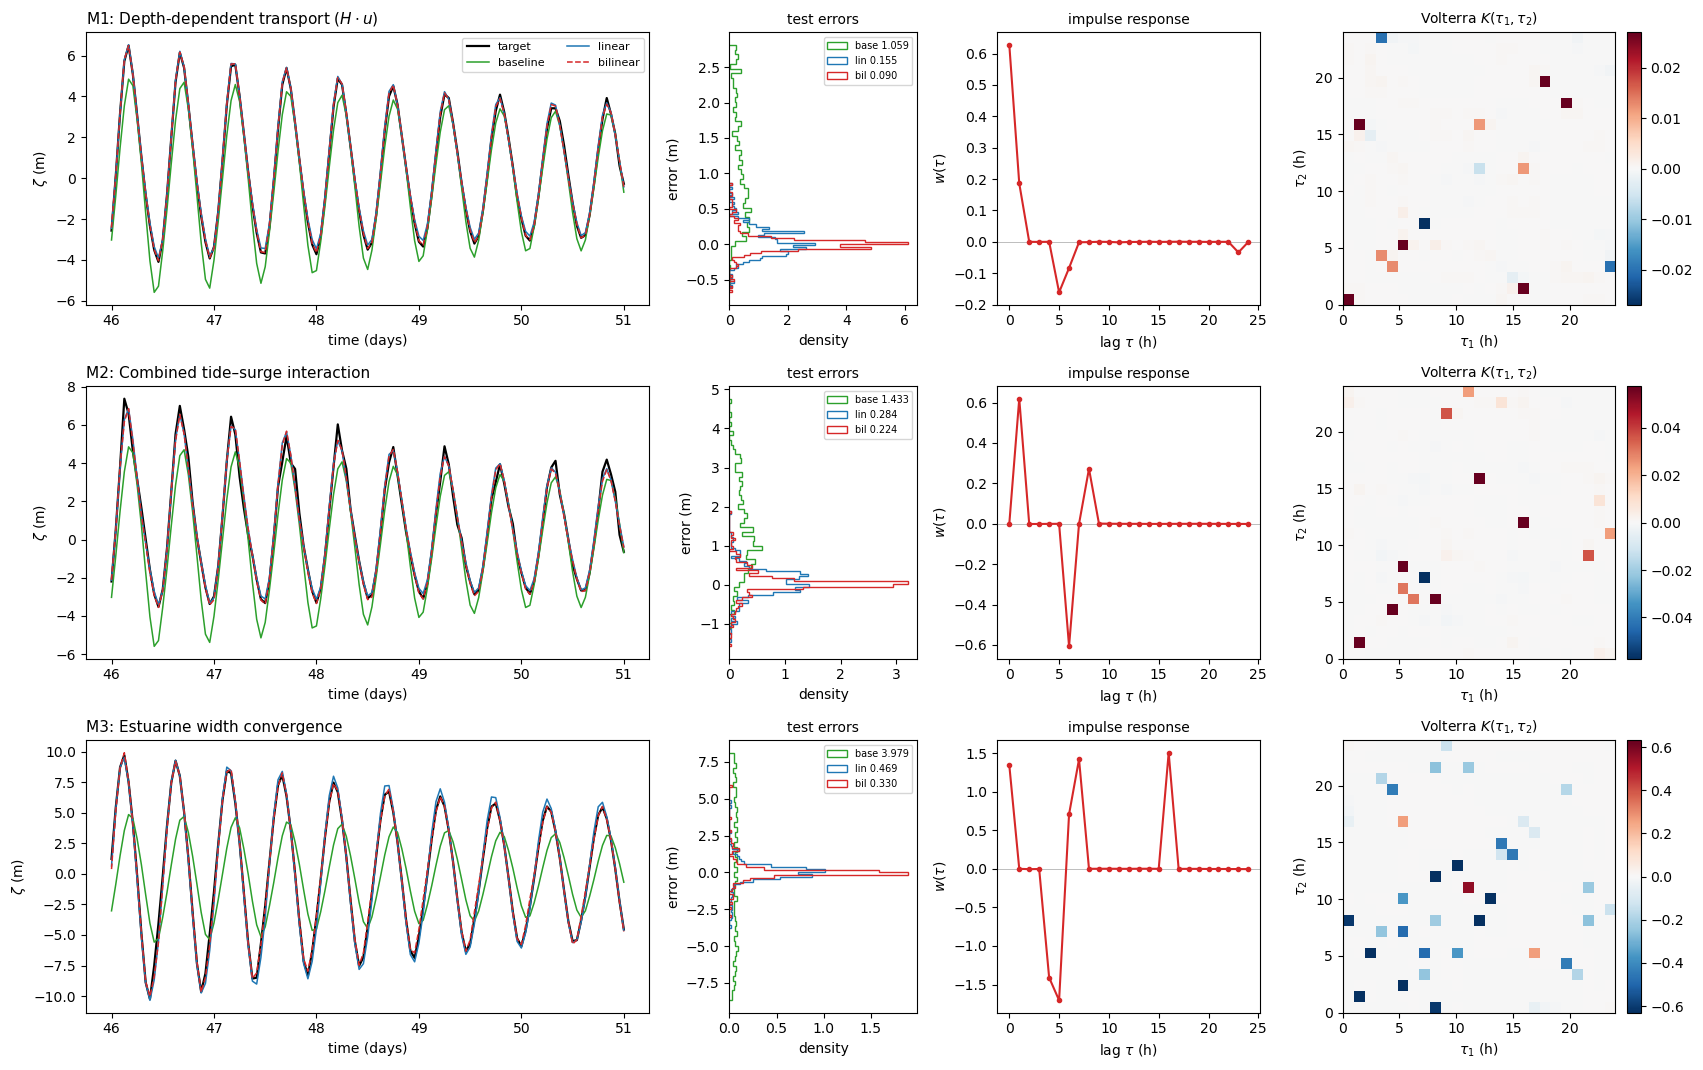

In [3]:
def linear_impulse(reg, cols):
    w = hm.extract_linear_lag_weights(reg, cols)
    w = w[w["is_lag_like"]].sort_values("lag_hours")
    return w["lag_hours"].to_numpy(), w["weight_mean"].to_numpy()

def volterra_kernel(reg, cols, max_lag=MAX_LAG):
    surf = hm.extract_bilinear_lag_surface(reg, cols)
    K = np.full((max_lag + 1, max_lag + 1), np.nan)
    for _, r in surf.iterrows():
        i, j = int(round(r["lag1_hours"])), int(round(r["lag2_hours"]))
        K[i, j] = K[j, i] = r["weight_mean"]
    return K

C = dict(target="k", base="#2ca02c", lin="tab:blue", bil="tab:red")
nrow = len(results)
fig, ax = plt.subplots(nrow, 4, figsize=(17, 3.6 * nrow),
                       gridspec_kw={"width_ratios": [3, 1, 1.4, 1.6]})
if nrow == 1: ax = ax[None, :]

for row, (exp, res) in enumerate(zip(experiments, results)):
    td, test = res["t_days"], res["test"]
    zm = (td >= ZOOM[0]) & (td <= ZOOM[1])

    a = ax[row, 0]
    a.plot(td[zm], res["y"][zm], color=C["target"], lw=1.6, label="target")
    a.plot(td[zm], res["x"][zm], color=C["base"], lw=1.1, label="baseline")
    a.plot(td[zm], res["yL"][zm], color=C["lin"], lw=1.1, label="linear")
    a.plot(td[zm], res["yB"][zm], color=C["bil"], lw=1.1, ls="--", label="bilinear")
    a.set_ylabel(r"$\zeta$ (m)"); a.set_title(exp["title"], loc="left", fontsize=11)
    a.set_xlabel("time (days)")
    if row == 0: a.legend(ncol=2, fontsize=8, loc="upper right")

    a = ax[row, 1]
    for key, c, lab in [("x", C["base"], "base"), ("yL", C["lin"], "lin"), ("yB", C["bil"], "bil")]:
        e = (res["y"] - res[key])[test]
        a.hist(e, bins=50, orientation="horizontal", histtype="step", color=c,
               density=True, label=f"{lab} {np.abs(e).mean():.3f}")
    a.set_xlabel("density"); a.set_ylabel("error (m)"); a.legend(fontsize=7)
    a.set_title("test errors", fontsize=10)

    a = ax[row, 2]
    lag, w = linear_impulse(res["regB"], res["colsB"])
    a.axhline(0, color="0.7", lw=0.6)
    a.plot(lag, w, color=C["bil"], marker="o", ms=3)
    a.set_xlabel(r"lag $\tau$ (h)"); a.set_ylabel(r"$w(\tau)$"); a.set_title("impulse response", fontsize=10)

    a = ax[row, 3]
    K = volterra_kernel(res["regB"], res["colsB"])
    vmax = np.nanpercentile(np.abs(K), 99) or 1e-6
    im = a.imshow(K, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax, extent=[0, MAX_LAG, 0, MAX_LAG])
    a.set_xlabel(r"$\tau_1$ (h)"); a.set_ylabel(r"$\tau_2$ (h)"); a.set_title(r"Volterra $K(\tau_1,\tau_2)$", fontsize=10)
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.04)

fig.tight_layout()

## 4. Frequency-domain view — admittance and the weighted QTF

The same operators seen in the frequency domain. The **linear admittance**
*|H(f)|* is how the operator re-weights each frequency; the **input-weighted
quadratic transfer function** *W(f₁,f₂) = |H₂(f₁,f₂)|·|X(f₁)||X(f₂)|* shows which
pairs of forcing frequencies the bilinear operator couples — the off-diagonal /
sum-frequency lobes are the tide–tide and tide–surge interactions. Everything
here comes straight from `hydromend.spectral`.

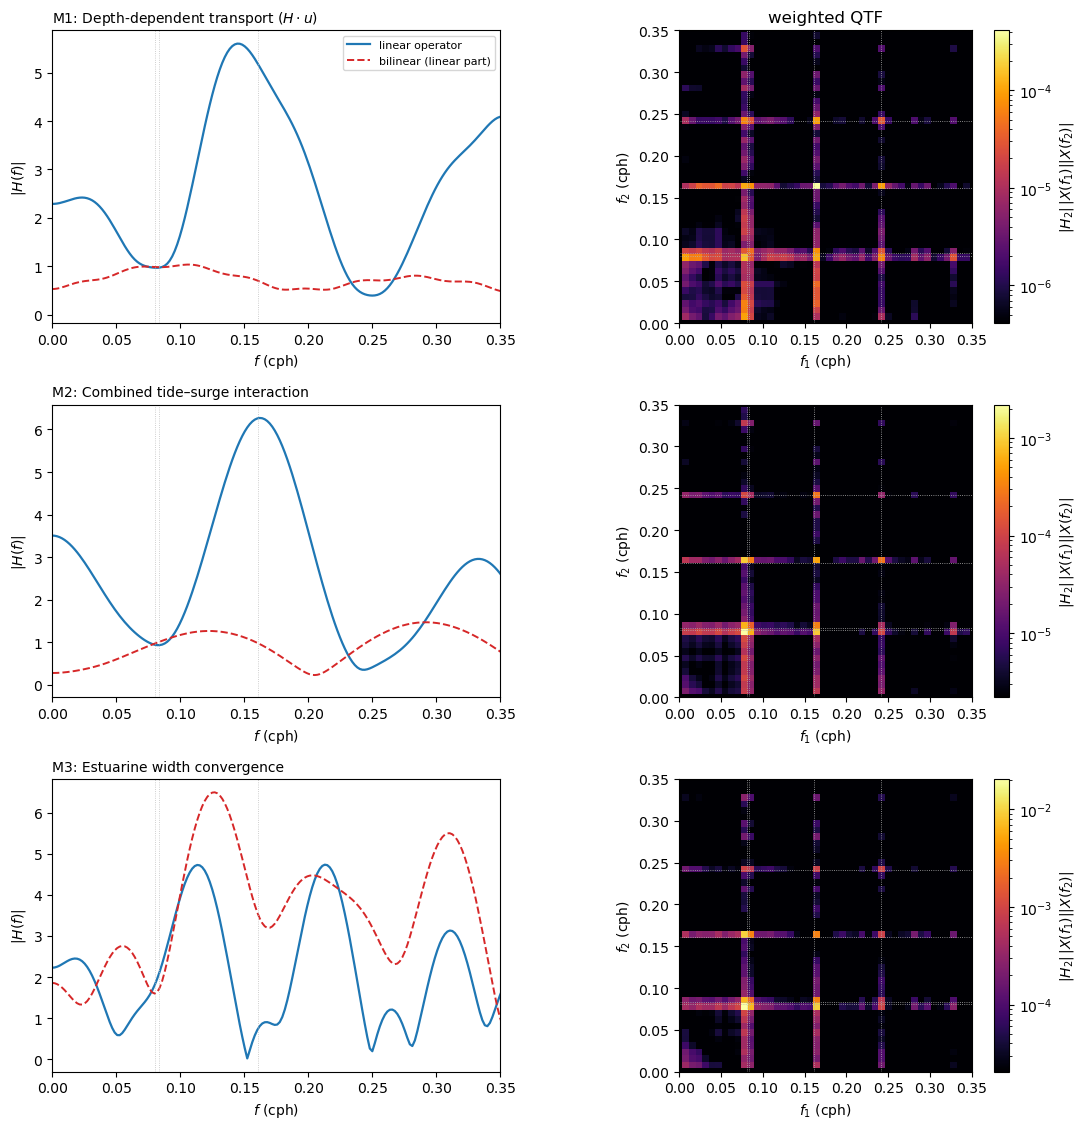

In [4]:
fig, ax = plt.subplots(nrow, 2, figsize=(11, 3.8 * nrow),
                       gridspec_kw={"width_ratios": [1.2, 1.5]})
if nrow == 1: ax = ax[None, :]

for row, (exp, res) in enumerate(zip(experiments, results)):
    a = ax[row, 0]
    fL, HL = hm.linear_admittance(res["regL"], res["colsL"])
    fB, HB = hm.linear_admittance(res["regB"], res["colsB"])
    a.plot(fL, np.abs(HL), color=C["lin"], lw=1.6, label="linear operator")
    a.plot(fB, np.abs(HB), color=C["bil"], lw=1.4, ls="--", label="bilinear (linear part)")
    for fr in (1/12.42, 1/12.00, 2/12.42):
        a.axvline(fr, color="0.75", ls=":", lw=0.6)
    a.set_xlim(0, 0.35); a.set_xlabel(r"$f$ (cph)"); a.set_ylabel(r"$|H(f)|$")
    a.set_title(exp["title"], loc="left", fontsize=10)
    if row == 0:
        a.legend(fontsize=8)

    fw, W = hm.weighted_quadratic_transfer(res["regB"], res["x"], res["colsB"])
    hm.plot_quadratic_transfer(fw, W, ax=ax[row, 1],
                               cbar_label=r"$|H_2|\,|X(f_1)||X(f_2)|$",
                               title="weighted QTF" if row == 0 else None)

fig.tight_layout()

## 5. Notes

* Each panel row is one *mechanism*: the baseline misses a piece of physics or
  geometry, and the operator learns to put it back. The **linear** operator
  captures the amplitude/phase correction; the **bilinear** operator additionally
  recreates the overtides and tide–surge interaction the mechanism generates —
  visible as structure on and off the diagonal of *K(τ₁,τ₂)*.
* The estimator is `hydromend`'s default `vb_ard` (variational-Bayes ARD). Swap
  in `make_regressor("gp_volterra")` for the GP-prior kernel used in the paper's
  smoother figures, or `"ols"` for a fast look.
* Every fitted operator can be serialised with `hm.Operator.from_regressor(...)`
  and shipped in an `OperatorLibrary`, exactly as in `quickstart.ipynb`.